# 🧠 Post-Pandemic Remote Work & Health Impact (2025)

| Sütun Adı                   | Açıklama                                                                              |
| --------------------------- | ------------------------------------------------------------------------------------- |
| **Survey_Date**             | Anketin uygulandığı tarih (YYYY-MM-DD formatında).                                    |
| **Age**                     | Katılımcının yaşı.                                                                    |
| **Gender**                  | Katılımcının cinsiyeti (ör. Male, Female, Non-binary vb.).                            |
| **Region**                  | Katılımcının bulunduğu bölge veya kıta (ör. Asia, Europe, North America).             |
| **Industry**                | Katılımcının çalıştığı sektör (ör. Education, Manufacturing, Professional Services).  |
| **Job_Role**                | Katılımcının iş pozisyonu veya unvanı (ör. Data Analyst, DevOps Engineer).            |
| **Work_Arrangement**        | Çalışma düzeni (ör. Remote, Onsite, Hybrid).                                          |
| **Hours_Per_Week**          | Haftalık ortalama çalışma saati.                                                      |
| **Mental_Health_Status**    | Katılımcının belirttiği zihinsel sağlık durumu (ör. Depression, Anxiety, ADHD, None). |
| **Burnout_Level**           | Katılımcının tükenmişlik düzeyi (ör. Low, Medium, High).                              |
| **Work_Life_Balance_Score** | İş-yaşam dengesi puanı (genellikle 1–5 arası, 5 = en dengeli).                        |
| **Physical_Health_Issues**  | Katılımcının yaşadığı fiziksel sağlık sorunları (ör. Back Pain, Eye Strain; None).    |
| **Social_Isolation_Score**  | Sosyal izolasyon düzeyi (muhtemelen 1–5 arası, yüksek değer = daha fazla izolasyon).  |
| **Salary_Range**            | Katılımcının maaş aralığı (ör. $40K–60K, $80K–100K).                                  |


## Veri Temizleme, Keşifsel Veri Analizi

---

### 📍 1. Giriş
Bu çalışma, pandemi sonrası dönemde uzaktan çalışmanın sağlık üzerindeki etkilerini anlamaya yöneliktir. Amaç, verideki kalıpları keşfetmek, aykırı değerleri (outlier) ve eksik verileri (missing values) uygun şekilde ele almak, ardından görselleştirmelerle ilişkileri analiz etmektir.

In [1]:
# !pip install pandas 
# !pip install missingno 
# !pip install plotly 
# !pip install folium  
# # pip install scipy  
# kütüp haneleri import edebilmek için install ettik 

In [2]:
!pip install pandas 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install missingno 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install plotly 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install folium 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install scipy 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # veri görselleştirmede kullanılan kütüphanedir 
import seaborn as sns #Seaborn, Matplotlib kütüphanesinin üzerine inşa edilmiş, 
                    #yüksek seviyeli ve kullanımı daha kolay bir veri görselleştirme kütüphanesidir.

import missingno as msno  # missingo, veri setindeki eksik verileri (NaN/Null) hızlıca tespit eder, bunların dağılımını görselleştirir
import plotly.express as px # plotly express interactive grafikler olusturmak icin kullanilir  
import folium  # Python verilerini etkileşimli (interaktif) haritalar üzerinde görselleştirmek için kullanılan en popüler kütüphanedir.
from folium import plugins #Folium haritasına standart özelliklerin ötesinde gelişmiş ve interaktif araçlar eklemek için kullanılır.

import warnings # versiyona bagli uyarilar gelebilir, bu uyarilari kapatmak icin ignore kullandık
warnings.filterwarnings("ignore")
warnings.warn("this will not show")


### 📂 2. Veriyi Tanıma

**Adımlar:**
- Veri setini pandas ile içe aktar.
- İlk 5–10 satırı görüntüle.
- Satır ve sütun sayısını belirle.
- Değişken tiplerini incele.
- Her sütunun kısa açıklamasını oluştur.

**Sorular:**
1. Veri setinde kaç gözlem ve kaç özellik var?
2. Sayısal ve kategorik sütunların oranı nedir?
3. Tarih veya zaman bilgisi içeren değişken var mı?

In [8]:
df0 = pd.read_csv("post_pandemic_remote_work_health_impact_2025.csv") # veri pd.read_csv() fonksiyonu ile df_0 olarak okundu,
df= df0.copy() # datada veri kaybı yaşamamak için veriyi kopyası oluşturuldu işlemler kopya üzerinden devam edilecektir. 
df

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,2025-06-26,62,Female,South America,Professional Services,Data Analyst,Hybrid,38,PTSD,Medium,4,Shoulder Pain; Neck Pain,3,$80K-100K
3153,2025-06-26,24,Female,South America,Professional Services,Software Engineer,Remote,54,NaN,Medium,4,Eye Strain,4,$100K-120K
3154,2025-06-26,45,Female,North America,Professional Services,HR Manager,Onsite,59,PTSD,Medium,1,Shoulder Pain,3,$40K-60K
3155,2025-06-26,38,Male,North America,Education,Operations Manager,Onsite,52,Depression,Medium,3,Shoulder Pain; Eye Strain; Neck Pain,5,$80K-100K


In [9]:
df.head() 
# ilk 5 satır görüntülende. head fonsiyonunun deefault değari 5 dir. 

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


In [10]:
df.head(10) 
# ilk 10 satır görüntülendi 

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K
5,2025-06-01,52,Male,Oceania,Customer Service,Business Analyst,Onsite,61,Burnout,Medium,4,Back Pain; Shoulder Pain,3,$60K-80K
6,2025-06-01,50,Female,Asia,Manufacturing,IT Support,Onsite,62,NaN,Medium,4,Back Pain; Shoulder Pain; Wrist Pain,2,$80K-100K
7,2025-06-01,63,Non-binary,Europe,Professional Services,Technical Writer,Onsite,55,Anxiety,High,3,NaN,2,$100K-120K
8,2025-06-01,30,Female,South America,Technology,Software Engineer,Remote,47,Anxiety,Medium,2,Neck Pain,4,$60K-80K
9,2025-06-01,37,Female,Asia,Finance,HR Manager,Onsite,55,Burnout,Medium,5,Back Pain,1,$60K-80K


In [11]:
df.tail() 
# son 5 satır görüntülendi. tail fonksiyonunun default değeri 5 tir. 

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
3152,2025-06-26,62,Female,South America,Professional Services,Data Analyst,Hybrid,38,PTSD,Medium,4,Shoulder Pain; Neck Pain,3,$80K-100K
3153,2025-06-26,24,Female,South America,Professional Services,Software Engineer,Remote,54,NaN,Medium,4,Eye Strain,4,$100K-120K
3154,2025-06-26,45,Female,North America,Professional Services,HR Manager,Onsite,59,PTSD,Medium,1,Shoulder Pain,3,$40K-60K
3155,2025-06-26,38,Male,North America,Education,Operations Manager,Onsite,52,Depression,Medium,3,Shoulder Pain; Eye Strain; Neck Pain,5,$80K-100K
3156,2025-06-26,54,Female,North America,Healthcare,Technical Writer,Onsite,39,Burnout,Medium,4,Back Pain; Eye Strain,2,$100K-120K


In [12]:
df.shape 
# Satır ve sütun sayısını gösterir. 
# data setinde 3157 satır, 14 sütun mevcuttur. 

(3157, 14)

In [13]:
df.columns # sütun isimlerini verir 

Index(['Survey_Date', 'Age', 'Gender', 'Region', 'Industry', 'Job_Role',
       'Work_Arrangement', 'Hours_Per_Week', 'Mental_Health_Status',
       'Burnout_Level', 'Work_Life_Balance_Score', 'Physical_Health_Issues',
       'Social_Isolation_Score', 'Salary_Range'],
      dtype='str')

In [14]:
df.dtypes
#  DataFrame yapısında data typenda: string ve integer(int64 = 64-bit Integer = 64-bit Tamsayı) veri tipi mevcuttur
# dtype: object -> karışık veri tipi anlamına gelir. Metinlerin sayıların pyhton objelerinin olduğu veri tipitir. 
# 4 tane int.dır, bu sütunlar Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score dır
# 10 tane str dtype sahip sütün vardır.Bunlar Survey_Date ,Gender,Region,Industry ,Job_Role, Work_Arrangement,Mental_Health_Status
# Burnout_Level ,Physical_Health_Issues ,Salary_Range . str datalar incelendiğinde kategorik özellikte dataların mevcut olduğu görüldü .
# dtypes yapısında düzenleme yapılmalıdır .

Survey_Date                  str
Age                        int64
Gender                       str
Region                       str
Industry                     str
Job_Role                     str
Work_Arrangement             str
Hours_Per_Week             int64
Mental_Health_Status         str
Burnout_Level                str
Work_Life_Balance_Score    int64
Physical_Health_Issues       str
Social_Isolation_Score     int64
Salary_Range                 str
dtype: object

In [15]:
df['Survey_Date'].value_counts() 
# value_counts() fonksiyonu ile ilgili sütunda unique(farklı) değerlerde kaç veri olduğunu gösterir


Survey_Date
2025-06-07    137
2025-06-04    136
2025-06-05    135
2025-06-23    135
2025-06-16    134
2025-06-12    132
2025-06-15    130
2025-06-21    129
2025-06-14    128
2025-06-22    128
2025-06-19    127
2025-06-03    125
2025-06-08    123
2025-06-18    121
2025-06-20    121
2025-06-17    120
2025-06-13    119
2025-06-06    118
2025-06-25    118
2025-06-11    117
2025-06-24    110
2025-06-02    107
2025-06-26    106
2025-06-09    102
2025-06-10    101
2025-06-01     98
Name: count, dtype: int64

In [16]:
print(df['Survey_Date'].dtype)
# data tipi datetime olarak düzeltilmelidir. Tarih veya zaman bilgisi içeren değişkende düzeltilmiştir 

str


In [17]:
type(df['Survey_Date'].iloc[0])
# Datadaki Survey_Date daki<ilk veriyi iloc ile indeksleyerek veri tipine bakıldı 
# Survey_Date YYYY.AY.GÜN şeklinde  tarih bilgisi  içerir fakat data tipi stringtir.

str

In [18]:
df['Survey_Date'] = pd.to_datetime(df['Survey_Date'])
# Survey_Date type datetime  pd.to_datetime fonksiyonu kullanılarak çevrildi 

print(df['Survey_Date'].dtype) 

# Tarih veya zaman bilgisi içeren değişken var mı? dytpe düzeltilerak sorusunun cevabı verilmiştir. 

datetime64[us]


In [20]:
df['Age'].value_counts() # Age sutunü  

Age
43    92
45    90
56    88
47    84
62    84
27    83
24    82
31    80
52    79
46    78
50    76
53    76
48    76
60    76
30    75
36    75
44    75
65    74
58    73
37    72
22    72
54    72
59    71
34    71
63    70
57    70
33    69
26    68
61    68
51    67
40    66
23    66
29    66
32    65
35    65
42    64
39    64
64    63
49    63
38    61
25    60
55    59
28    58
41    51
Name: count, dtype: int64

In [21]:
df['Age'].min() # min ve max değerlere göre yaş aralığı belirlenebilir

np.int64(22)

In [22]:
df['Age'].max()

np.int64(65)

In [23]:
df['Gender'].value_counts() # 4 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Gender
Male                 1535
Female               1500
Non-binary             90
Prefer not to say      32
Name: count, dtype: int64

In [24]:
df['Region'].value_counts() # 6 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Region
South America    575
Africa           532
Oceania          523
Asia             517
Europe           513
North America    497
Name: count, dtype: int64

In [25]:
df['Industry'].value_counts() # 10 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Industry
Professional Services    730
Technology               593
Manufacturing            370
Finance                  367
Education                287
Healthcare               247
Marketing                202
Retail                   188
Customer Service         173
Name: count, dtype: int64

In [26]:
df['Job_Role'].value_counts() # 25 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Job_Role
Research Scientist              151
DevOps Engineer                 149
Social Media Manager            144
Customer Service Manager        144
Data Analyst                    143
Operations Manager              142
HR Manager                      141
IT Support                      140
Project Manager                 136
Data Scientist                  136
Product Manager                 133
UX Designer                     132
Account Manager                 132
Quality Assurance               132
Business Analyst                131
Software Engineer               128
Consultant                      121
Digital Marketing Specialist    119
Executive Assistant             119
Marketing Specialist            119
Technical Writer                118
Content Writer                  117
Financial Analyst               116
Sales Representative            114
Name: count, dtype: int64

In [27]:
df['Work_Arrangement'].value_counts() # 3 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Work_Arrangement
Onsite    1562
Hybrid    1007
Remote     588
Name: count, dtype: int64

In [28]:
df['Hours_Per_Week'].value_counts()

Hours_Per_Week
45    123
55    119
50    117
56    117
64    113
44    113
40    111
36    110
57    110
47    109
43    108
53    105
49    104
60    104
59    102
65    101
39    101
35    100
46     99
38     98
48     98
37     97
62     94
58     93
42     93
54     90
63     89
52     89
41     87
61     83
51     80
Name: count, dtype: int64

In [29]:
df['Hours_Per_Week'].min() # min ve max değerlere göre çalışma saat aralığı belirlenebilir

np.int64(35)

In [30]:
df['Hours_Per_Week'].max()

np.int64(65)

In [31]:
df['Mental_Health_Status'].value_counts() # 6 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Mental_Health_Status
PTSD               423
Anxiety            394
Burnout            392
Depression         386
ADHD               385
Stress Disorder    378
Name: count, dtype: int64

In [32]:
df['Burnout_Level'].value_counts() # 3 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Burnout_Level
Medium    1366
High      1046
Low        745
Name: count, dtype: int64

In [33]:
df['Work_Life_Balance_Score'].value_counts()

Work_Life_Balance_Score
3    1169
4     655
2     572
1     404
5     357
Name: count, dtype: int64

In [34]:
df['Physical_Health_Issues'].value_counts() 

Physical_Health_Issues
Shoulder Pain; Eye Strain                                      262
Back Pain; Eye Strain                                          258
Eye Strain                                                     256
Back Pain; Shoulder Pain; Eye Strain                           255
Back Pain                                                      253
Shoulder Pain                                                  235
Back Pain; Shoulder Pain                                       218
Back Pain; Eye Strain; Neck Pain                                93
Neck Pain                                                       92
Eye Strain; Neck Pain                                           90
Back Pain; Shoulder Pain; Eye Strain; Neck Pain                 88
Back Pain; Neck Pain                                            88
Shoulder Pain; Neck Pain                                        78
Shoulder Pain; Eye Strain; Neck Pain                            76
Back Pain; Shoulder Pain; Neck Pain    

In [35]:
df['Physical_Health_Issues'].str.split('; ').explode().unique()
print(df['Physical_Health_Issues'].str.split('; ').explode().unique())
# df['Physical_Health_Issues'].value_counts()  çıktısında değerler ';' ile ayrılarak sayıldığı için tekrar eden değerler vardır. 
# Physical_Health_Issues sütunundaki unique değerlerini bulmak için split fonksiyonu ile ; den ayırdık ,
# explode fonksiyonu ile ayrı satırda yazdırdık unique özellikler geldi 

<ArrowStringArray>
['Shoulder Pain', 'Neck Pain', 'Back Pain', 'Eye Strain', nan, 'Wrist Pain']
Length: 6, dtype: str


In [36]:
df['Social_Isolation_Score'].value_counts() 

Social_Isolation_Score
3    929
2    856
1    571
4    536
5    265
Name: count, dtype: int64

In [37]:
df['Salary_Range'].value_counts() # maaş aralığı 5 kategoriden oluşuyor dytpe categoriye çevrilebilir 

Salary_Range
$60K-80K      1014
$80K-100K      964
$40K-60K       510
$100K-120K     459
$120K+         210
Name: count, dtype: int64

In [38]:
# dytpeları düzenlersek ;
df[[
    "Gender",
    "Region",
    "Industry",
    "Job_Role",
    "Work_Arrangement",
    "Mental_Health_Status",
    "Burnout_Level",
    "Physical_Health_Issues",
    'Salary_Range'
]] = df[[
    "Gender",
    "Region",
    "Industry",
    "Job_Role",
    "Work_Arrangement",
    "Mental_Health_Status",
    "Burnout_Level",
    "Physical_Health_Issues",
    'Salary_Range'
]].astype("category") # kategorik sütunların dtypeları değiştirilmiştir. 

In [39]:
df.dtypes

# verinin son durumda düzenlenmiş dtypes ları 

Survey_Date                datetime64[us]
Age                                 int64
Gender                           category
Region                           category
Industry                         category
Job_Role                         category
Work_Arrangement                 category
Hours_Per_Week                      int64
Mental_Health_Status             category
Burnout_Level                    category
Work_Life_Balance_Score             int64
Physical_Health_Issues           category
Social_Isolation_Score              int64
Salary_Range                     category
dtype: object

**Her sütunun kısa açıklamasını oluştur:**
<small>
 1. Survey_Date :String dytpe formatında olup anketin yapıldığı tarih bilgisini yıl-ay-gün şeklinde belirtilmiştir. 01.06.2925- 26.06.2025 tarihleri arasında 3157 kişi ankete katılım sağlamıştır. Datatipi datetime olarak güncellenmiştir

 2. Age: Integer dytpe formatında olup, 3157 katılımcının yaş aralığı 22 ve 65 yaştır.

 3. Gender: String dytpe formatında olup katılımcının cinsiyetini belirtir. Data setinde cinsiyet sütunundaki 4 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** Erkek (male) 1535 
        ** Kadın (Female) 1500 
        ** Non-binary 90 
        ** Söylememeyi tercih eden 32 şeklindedir. Datatipi category olarak güncellenmiştir


4. Region: String dytpe formatında olup katılımcının yaşadığı bölgeyi belirtir. Data setinde region sütunundaki 6 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** South America (Güney Amerika) 575
        ** Africa (Afrika) 532
        ** Oceania (Okyanusya :Avustralya, Melanezya, Polinezya ve Mikronezya) 523
        ** Asia (Asya) 517
        ** Europe (Avrupa) 513 
        ** North America (Kuzey Amerika) 497 şeklindedir.  Datatipi category olarak güncellenmiştir

5. Industry: String dytpe formatında olup katılımcının çalıştığı sektörü belirtir. Data setinde industry sütunundaki 9 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** Professional Services (Profesyonel Hizmetler) 730
        ** Technology (Teknoloji)  593
        ** Manufacturing (Üretim) 370
        ** Finance (Finans)367
        ** Education (Eğitim) 287 
        ** Healthcare (Sağlık) 247
        ** Marketing (Pazarlama) 202
        ** Retail (Perakende) 188
        ** Customer Service (Müşteri Hizmetleri ) 173 şeklindedir.  Datatipi category olarak güncellenmiştir

5. Job_Role: String dytpe formatında olup katılımcının iş rolü- görevini-pozisyonunu belirtir. Data setinde Job_Role sütunundaki 24 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** Research Scientist (Araştırma Bilimcisi) 151
        ** DevOps Engineer (DevOps Mühendisi) 149
        ** Social Media Manager (Sosyal Medya Yöneticisi) 144
        ** Customer Service Manager (Müşteri Hizmetleri Yöneticisi) 144
        ** Data Analyst (Veri Analisti ) 143
        ** Operations Manager (Operasyon Yöneticisi)142
        ** HR Manager(İnsan Kaynakları Yöneticisi) 141
        ** IT Support (BT Destek) 140
        ** Project Manager (Proje Yöneticisi) 136
        ** Data Scientist (Veri Bilimcisi) 136
        ** Product Manager (Ürün Yöneticisi) 133
        ** UX Designer (UX Tasarımcısı) 132
        ** Account Manager (Hesap Yöneticisi) 132
        ** Quality Assurance (Kalite Güvencesi) 132
        ** Business Analyst (İş Analisti) 131
        ** Software Engineer (Yazılım Mühendisi) 128
        ** Consultant (Danışman) 121
        ** Digital Marketing Specialist (Dijital Pazarlama Uzmanı) 119      
        ** Executive Assistant(Yönetici Asistanı) 119
        ** Marketing Specialist (Pazarlama Uzmanı) 119
        ** Technical Writer (Teknik Yazar) 118 
        ** Content Writer (İçerik Yazarı) 117 
        ** Financial Analyst (Finansal Analist) 116 
        ** Sales Representative (Satış Temsilcisi) 114  şeklindedir.  Datatipi category olarak güncellenmiştir

7. Work_Arrangement: String dytpe formatında olup katılımcının çalışma düzeni  belirtir. Data setinde Work_Arrangement sütunundaki 3 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** Onsite (İşyerinde) 1562 
        ** Hybrid (Hibrit) 1007
        ** Remote (Uzaktan) 588  şeklindedir.  Datatipi category olarak güncellenmiştir

8. Hours_Per_Week : Integer dytpe formatında olup, 3157 katılımcının haftalık çalışma saati minimum 35 ve maksimum 65 saat aralığında değişmektedir. 

9. Mental_Health_Status: String dytpe formatında olup katılımcının zihinsel sağlık durumunu belirtir. Data setinde Mental_Health_Status sütunundaki 6 özelliğe 799 katılımcı cevap vermemiş boş bırakmış, 2358 katılımcının verdiği cevaplara göre dağılım ise;
        ** PTSD  423 kişi
        ** Anxiety 394 kişi
        ** Burnout (Tükenmişlik) 392 kişi
        ** Depression (Depresyon) 386 kişi
        ** ADHD 385 kişi kişi
        ** Stress Disorder (Sters Bozukluğu) 378 kişi şeklindedir.  Datatipi category olarak güncellenmiştir

10. Burnout_Level: String dytpe formatında olup katılımcının tükenmişlik seviyesini belirtir. Data setinde Burnout_Level sütunundaki 3 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** Medium (Orta seviye) 1366 
        ** High (Yüksek seviye) 1046 
        ** Low (Düşük Seviye) 745   şeklindedir.  Datatipi category olarak güncellenmiştir

11. Work_Life_Balance_Score: String dytpe formatında olup katılımcının iş yaşam degesi puanını belirtir. Data setinde  Work_Life_Balance_Score sütunundaki 1-2-3-4-5 şeklinde puanlama ile belirtilen özelliğine  3157 katılımcının verdiği cevaplara göre dağılımı;
        ** 3 puan ->   1169 kişi
        ** 4 puan ->   655 kişi
        ** 2 puan ->   572 kişi
        ** 1 puan ->   404 kişi
        ** 5 puan ->   357 kişi  şeklindedir.

12. Physical_Health_Issues : String dytpe formatında olup, 3157 katılımcıdan 280'ni  cevap vermemiş boş bırakmış, 2877 kişi ise çeşitli fiziksel sağlık sorunları olduğunu belirtmiştir. Bunlar, Sholder Pain (Omuz Ağrısı) , Neck Pain (Boyun Ağrısı), Back Pain (Sırt Ağrısı), Eye Strain (Göz Yorgunluğu), Wrist Pain (Bilek Ağrısı)dır. Fiziksel sağlık sorunlardında katılımcılar en az sırt ağrısından , en çok bilek ağrısının olduğundan şikayetçidirler.  Datatipi category olarak güncellenmiştir

13. Social_Isolation_Score: Integer dytpe formatında olup katılımcının sosyal izalasyon puanını belirtir. Data setinde  Social_Isolation_Score sütunundaki 1-2-3-4-5 şeklinde puanlama ile belirtilen özelliğine 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** 3 puan ->   929 kişi
        ** 2 puan ->   856 kişi
        ** 1 puan ->   571 kişi
        ** 4 puan ->   536 kişi
        ** 5 puan ->   265 kişi  şeklindedir.

14. Salary_Range : String dytpe formatında olup katılımcının maaş aralığını belirtir. Data setinde Salary_Range sütunundaki 5 özelliğe 3157 katılımcının verdiği cevaplara göre dağılımı;
        ** $60K-80K maaş aralığı   -> 1014 kişi
        ** $80K-100K maaş aralığı  -> 964 kişi
        ** $40K-60K maaş aralığı   -> 510 kişi
        ** $100K-120K maaş aralığı -> 459 kişi
        ** $120K+ maaş aralığı     -> 210 kişi şeklindedir.  Datatipi category olarak güncellenmiştir
<small>

In [40]:
df.info()

# Datanın Genel Yapısı;
        # Katılımcıların bulunduğu 3157 tane satır 
        # Özelliklerin belirtildiği 14 colums (sütun) oluşur.

# NULL Değer Varlığı;
        # Datanın 12 sütunu tam dolu null değer yok . 2 sütununda null değer mevcuttur. 
                ## Mental_Health_Status, 2358 dolu ve 799 null (boş) değer vardır 
                ##Physical_Health_Issues, 2877 dolu ve 280 null (boş) değer vardır. 

# Data dtypes : 
        # 1 sütun (özelliğin ) type  datetime64[us] dir, 
        # 4 sütun (özelliğin ) type integerdır (Age, Hours_Per_Week,Work_Life_Balance_Score, Social_Isolation_Score )
        # 9 sütun (özelliğin ) type category dir 

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Survey_Date              3157 non-null   datetime64[us]
 1   Age                      3157 non-null   int64         
 2   Gender                   3157 non-null   category      
 3   Region                   3157 non-null   category      
 4   Industry                 3157 non-null   category      
 5   Job_Role                 3157 non-null   category      
 6   Work_Arrangement         3157 non-null   category      
 7   Hours_Per_Week           3157 non-null   int64         
 8   Mental_Health_Status     2358 non-null   category      
 9   Burnout_Level            3157 non-null   category      
 10  Work_Life_Balance_Score  3157 non-null   int64         
 11  Physical_Health_Issues   2877 non-null   category      
 12  Social_Isolation_Score   3157 non-null   int6

2. Sayısal ve kategorik sütunların oranı nedir?

In [41]:
toplam_sutun = df.shape[1] 
sayisal_sutun = len(df.select_dtypes(include = ['int']).columns)
kategorik_sutun = len(df.select_dtypes(include = ['category']).columns)

sayisal_oran = (sayisal_sutun / toplam_sutun) * 100
kategorik_oran = (kategorik_sutun / toplam_sutun) * 100

print(f'Sayısal Sütun Oranı : %{sayisal_oran:.2f}')
print(f'Kategorik Sütun Oranı : %{kategorik_oran:.2f}')

# hesap yapabilmek için toplam sütun sayısına sayısal (int,float), kategorik  değerlerin toplamına ihtiyacımız var 
# toplam_sutun = df.shape[1]  shapede önce satır(0), sonra sütun(1)değeri geldiği için indexledik.
# df.select_dtypes(include = ['int','float']).columns ile DataFrame da istediğimiz typeleri sütunlardan seçtik 
# len fonksiyonu ile veri setinde kaçtane kategorik veya sayısal değer olduğunu saydık 

Sayısal Sütun Oranı : %28.57
Kategorik Sütun Oranı : %64.29


### 🧹 3. Eksik Verilerle (Missing Values) Mücadele

**Adımlar:**
- Eksik veri oranlarını kontrol et.
- Eksiklik oranı yüksek sütunları belirle.
- Doldurma veya silme stratejisi belirle.

**Sorular:**
1. En çok eksik veriye sahip sütun hangisi?
2. Eksik veriler belirli gruplarda yoğunlaşıyor mu?
3. Eksik değerleri silmek mi doldurmak mı daha uygun?

In [42]:
df.isnull().sum()
# Mental_Health_Status  sutünunda 799 null değer vardır Ençok eksik veriye sahip olan sutundur
# Physical_Health_Issues  sutününda 280 null değer vardır 

Survey_Date                  0
Age                          0
Gender                       0
Region                       0
Industry                     0
Job_Role                     0
Work_Arrangement             0
Hours_Per_Week               0
Mental_Health_Status       799
Burnout_Level                0
Work_Life_Balance_Score      0
Physical_Health_Issues     280
Social_Isolation_Score       0
Salary_Range                 0
dtype: int64

In [43]:
df.isnull().sum().idxmax() 
#En çok eksik veriye sahip sütun

'Mental_Health_Status'

In [44]:
df.isnull().sum().sum()

np.int64(1079)

In [45]:
eksik_veri_oranı = (df.isnull().sum() / len(df)) * 100
print(eksik_veri_oranı)
# DataFrame dan eksik değerlerin yüzdesini hesaplanır 

Survey_Date                 0.000000
Age                         0.000000
Gender                      0.000000
Region                      0.000000
Industry                    0.000000
Job_Role                    0.000000
Work_Arrangement            0.000000
Hours_Per_Week              0.000000
Mental_Health_Status       25.308838
Burnout_Level               0.000000
Work_Life_Balance_Score     0.000000
Physical_Health_Issues      8.869180
Social_Isolation_Score      0.000000
Salary_Range                0.000000
dtype: float64


In [46]:
eksik_veri_oranı[eksik_veri_oranı > 0].sort_values(ascending=False)
# Eksik oranların 0 dan büyük olanları sort_values(ascending=False) fonksiyonu ile büyükten küçüğe sıraladık 
# Dataframe  Mental_Health_Status %25,31 ile en yüksek eksik veriye sahip özelliktir. 
# 

Mental_Health_Status      25.308838
Physical_Health_Issues     8.869180
dtype: float64

2. Eksik veriler belirli gruplarda yoğunlaşıyor mu?

In [47]:
df["mh_null"] = df["Mental_Health_Status"].isnull()
df["ph_null"] = df["Physical_Health_Issues"].isnull()
# eksiklikleri gruplarda analiz edebilmek için değişken oluşturduk 

In [48]:
columns = ["Gender","Region","Industry","Job_Role","Work_Arrangement"] #incelenecek sütunları grupladık 

for column in columns: # columns içinde liste oluşturur
    print("\n", column) # her çıktı için başlık yazdırır
    print(df.groupby(column)["mh_null"].mean().sort_values(ascending=False))
     # column içinde Mental_Health_Status deki null değerlerin ortalamasını küçükten büyüğe sıralar 

# Mental_Health_Status deki eksik değerler 
    # Gender sutununda özelliklere göre erkeklerde mental health sorusunu cevaplamama oranı biraz daha yüksek.
    # Region mental health verisi bazı bölgelerde daha az paylaşılmış.Batı bölgelerinde eksik veri daha fazla
    # Industry education sektöründe eksik veri en yüksek menthal health sorularını daha az yanıtlamış   
    # Job_Role sütununda Financial Analyst statüsünde eksik veri en yüksektir. 
    # Work_Arrangement en yüksek eksik veri remote kategorisindedir 


 Gender
Gender
Prefer not to say    0.343750
Non-binary           0.288889
Male                 0.259283
Female               0.242667
Name: mh_null, dtype: float64

 Region
Region
Oceania          0.279159
Europe           0.278752
North America    0.269618
South America    0.252174
Asia             0.220503
Africa           0.219925
Name: mh_null, dtype: float64

 Industry
Industry
Education                0.292683
Manufacturing            0.275676
Technology               0.264755
Retail                   0.260638
Finance                  0.245232
Marketing                0.237624
Professional Services    0.236986
Healthcare               0.230769
Customer Service         0.225434
Name: mh_null, dtype: float64

 Job_Role
Job_Role
Financial Analyst               0.336207
Technical Writer                0.330508
Digital Marketing Specialist    0.310924
Data Analyst                    0.279720
Marketing Specialist            0.277311
Operations Manager              0.267606
Business A

In [49]:
columns = ["Gender","Region","Industry","Job_Role","Work_Arrangement"]

for column in columns:
    print("\n", column)
    print(df.groupby(column)["ph_null"].mean().sort_values(ascending=False))

# Physical_Health_Issues deki eksik değerler 
    # Gender sutununda özelliklere göre Non-binary bireylerde fiziksel sağlık bilgisini paylaşmada daha çekingen.
    # Non-binary bireylerin bu durumu  gizlilik hassasiyeti ,sağlık verisi paylaşma güvensizliği ,kurum içi görünürlük kaygısı olabilir 
    # Region fiziksel sağlık bilgisini verisinde bölgesel olarak kutuplaşma olmamıştır.
    # Industry Retail,Manufacturing sektöründe eksik veri en yüksek fiziksel sağlık sorunları daha az raporlanmış.İş kaybı endişesi olabilir 
    # Job_Role sütununda Digital Marketing Specialist statüsünde eksik veri en yüksektir. 
    # Work_Arrangement  remote kategorisi fiziksel sağlık bilgilerini daha açık paylaşmış.


 Gender
Gender
Non-binary           0.111111
Prefer not to say    0.093750
Male                 0.089902
Female               0.086000
Name: ph_null, dtype: float64

 Region
Region
Oceania          0.097514
South America    0.093913
Africa           0.090226
Asia             0.087041
North America    0.082495
Europe           0.079922
Name: ph_null, dtype: float64

 Industry
Industry
Retail                   0.106383
Manufacturing            0.105405
Professional Services    0.097260
Healthcare               0.093117
Finance                  0.087193
Technology               0.082631
Marketing                0.079208
Customer Service         0.075145
Education                0.059233
Name: ph_null, dtype: float64

 Job_Role
Job_Role
Digital Marketing Specialist    0.151261
Financial Analyst               0.137931
Sales Representative            0.122807
Social Media Manager            0.111111
Data Scientist                  0.102941
HR Manager                      0.099291
Quality As

3. Eksik değerleri silmek mi doldurmak mı daha uygun?

In [50]:
df.isnull()
# Eksik veri oranları Mental_Health_Status %25,31 ve Physical_Health_Issues %8,87 değerde olduğu için silmek 
# ciddi veri kaybına sebep olur 
# Mental_Health_Status  ve Physical_Health_Issues iki kategorik özellik category yapıda olduğu için mode ile eksik değerler doldurulmalıdır
# false değerler doluluğu True değerler null veriyi gösterir 

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range,mh_null,ph_null
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3153,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3154,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3155,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

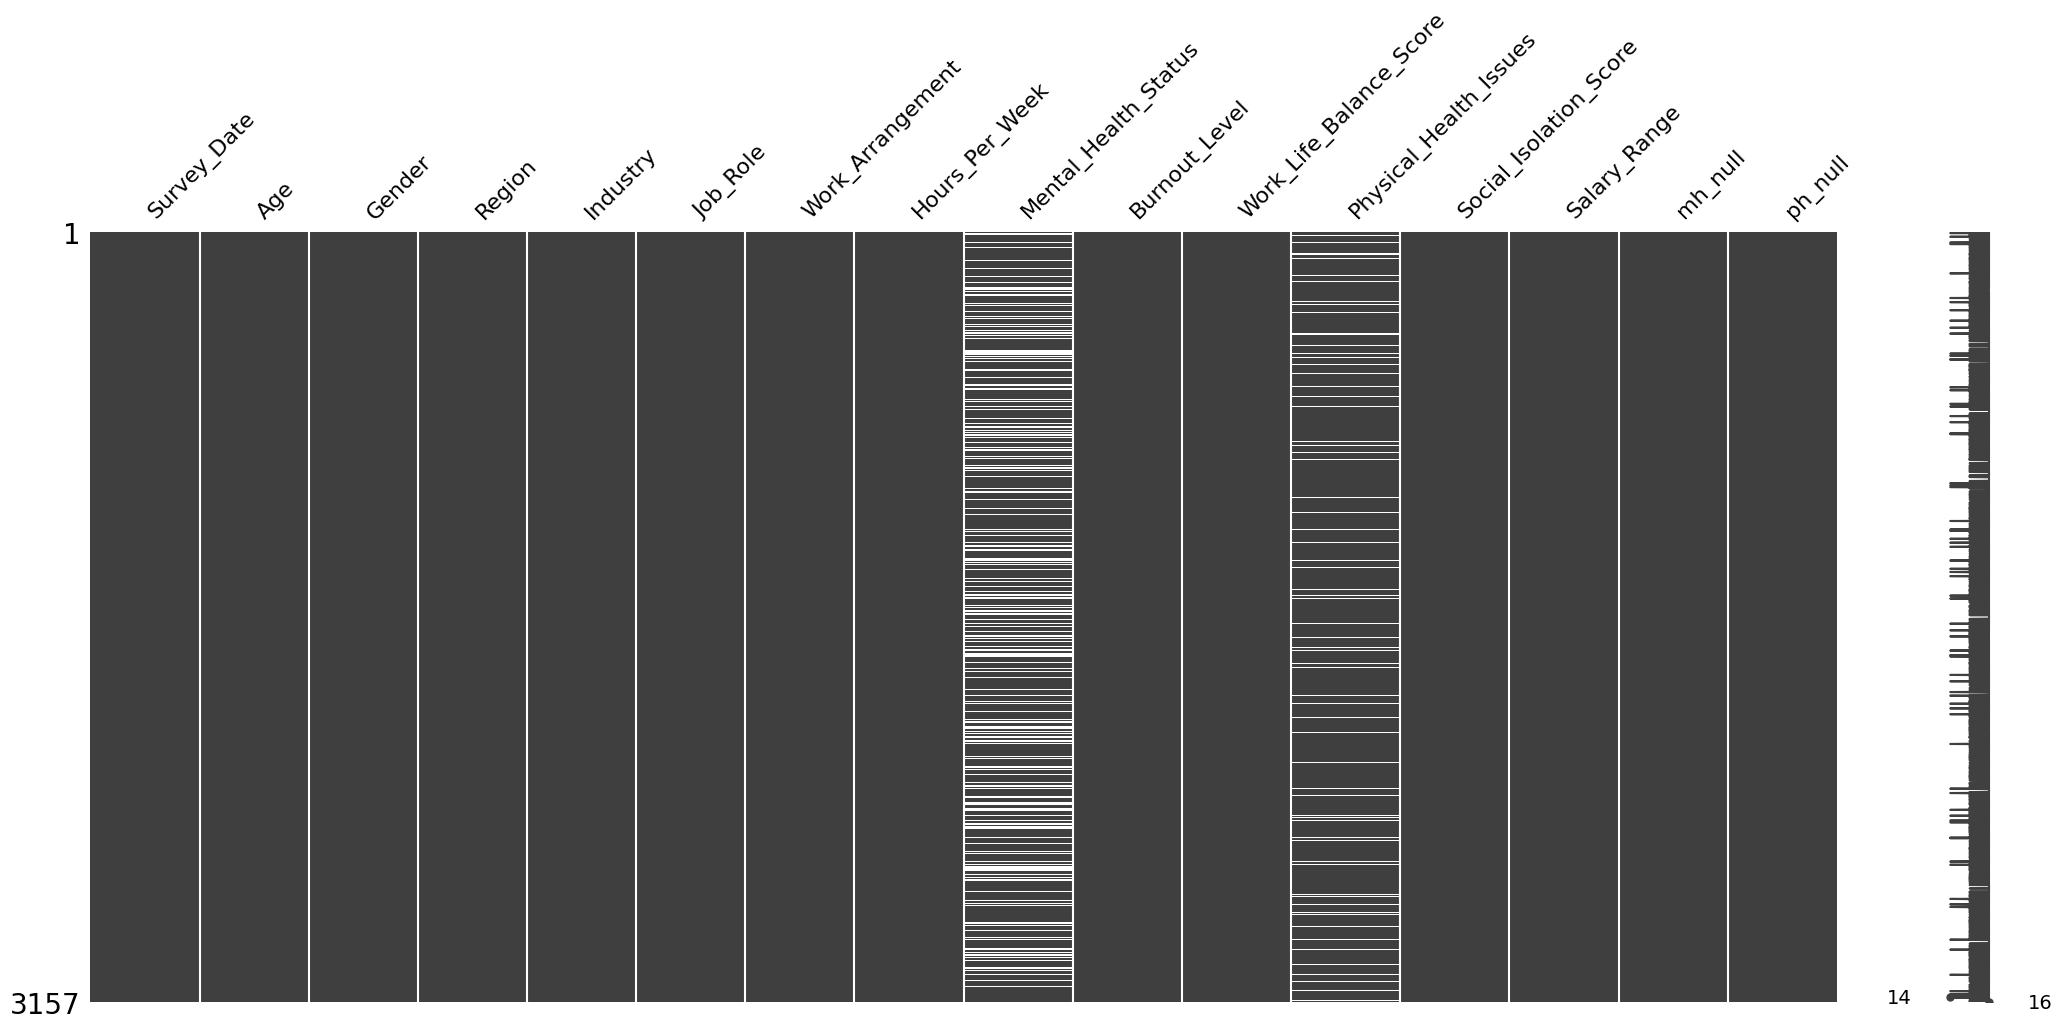

In [51]:
msno.matrix(df) # Datada hangi sütunda veride null değerlerin  olduğunu grafikle gösterdik . 
# dolu olan sütunlarda null değer yok, rating_count sütunundaki boşluklar null değer olduğunu gösterir 

In [46]:
df['Mental_Health_Status'].mode()

0    PTSD
Name: Mental_Health_Status, dtype: category
Categories (6, str): ['ADHD', 'Anxiety', 'Burnout', 'Depression', 'PTSD', 'Stress Disorder']

In [52]:
# Mental_Health_Status sutünunun mode (en çok tekrar eden değer) -> PTSD dir 
# Mental_Health_Status sütunundaki boş değerler PTSD ile doldurulur. 
# df de doldurma işleme inplace=true ile kalıcı hale getirildi kontrol edildi

df['Mental_Health_Status'] = df['Mental_Health_Status'].fillna(df['Mental_Health_Status'].mode()[0], inplace= True)
df['Mental_Health_Status'].isnull().sum()

np.int64(0)

In [53]:
df['Physical_Health_Issues'] = df['Physical_Health_Issues'].astype(str) #data tipi category iken işlem yapılamadığı için str yapıldı 

In [54]:
df['Physical_Health_Issues'].dropna().str.split('; ').explode().str.strip().mode().iloc[0]
# str.split(';')  ile ayır
# explode() listeyi tek tek satırlara aç, benzersiz değerleri satırlara yaz 
# mode() en sık tekrar eden değer


'Eye Strain'

In [55]:
# Physical_Healthssues sutünunun mode (en çok tekrar eden değer) ->  Eye Strain dir 
# Physical_Healthssues sütunundaki boş değerler  Eye Strain ile doldurulur. 
# df_3 de doldurma işleme inplace=true ile kalıcı hale getirildi kontrol edildi 
df['Physical_Health_Issues'] = df['Physical_Health_Issues'].fillna(df['Physical_Health_Issues'].str.split('; ').explode().mode()[0], inplace= True)
df['Physical_Health_Issues'].isnull().sum()

np.int64(0)

In [56]:
df.isnull().sum().sum()

np.int64(0)

<Axes: >

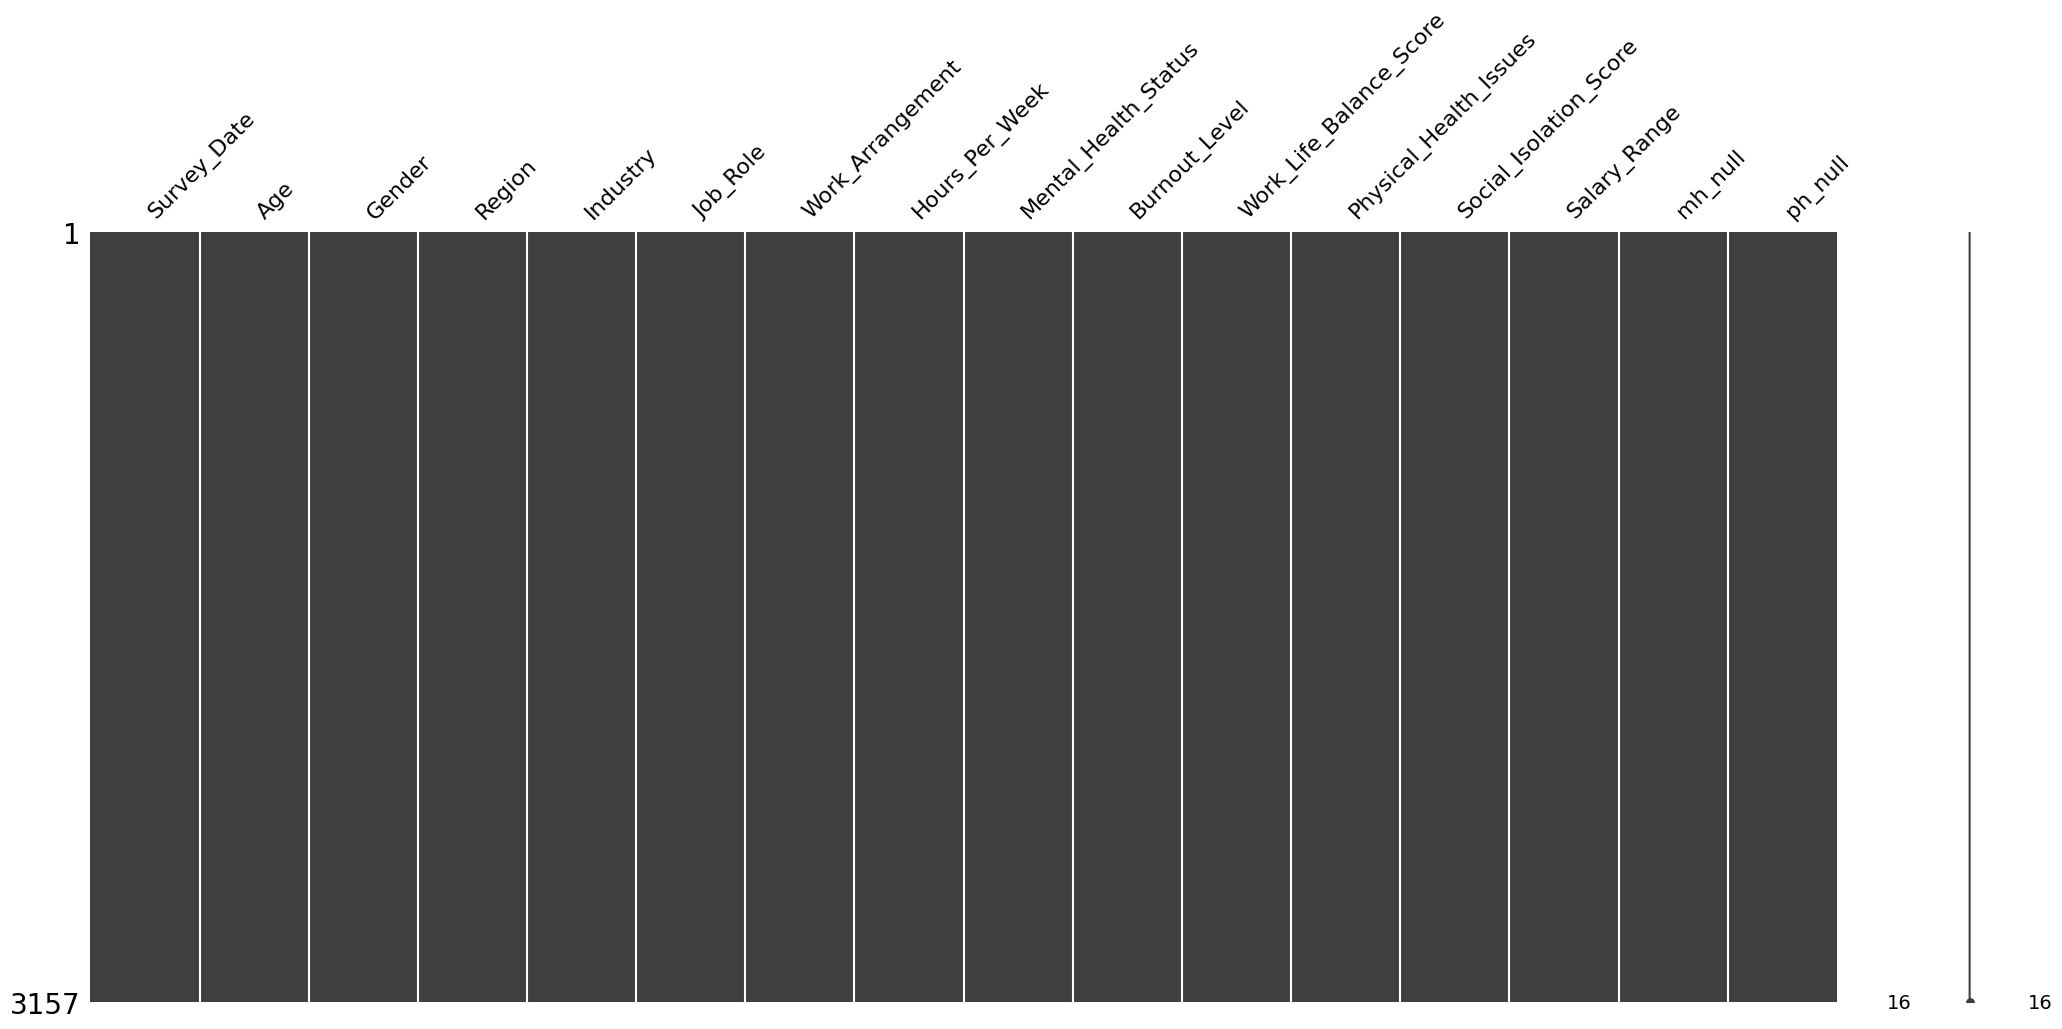

In [57]:
msno.matrix(df) # Datada hangi sütunda veride null değerlerin  doldurulduğunu grafikle gösterdik . 
# dolu olan sütunlarda null değer yok, rating_count sütunundaki boşluklar null değer olduğunu gösterir 

In [58]:
df['Physical_Health_Issues'] = df['Physical_Health_Issues'].astype('category')
 #data tipi category iken işlem yapılamadığı için str yapıldı 
df.dtypes

Survey_Date                datetime64[us]
Age                                 int64
Gender                           category
Region                           category
Industry                         category
Job_Role                         category
Work_Arrangement                 category
Hours_Per_Week                      int64
Mental_Health_Status             category
Burnout_Level                    category
Work_Life_Balance_Score             int64
Physical_Health_Issues           category
Social_Isolation_Score              int64
Salary_Range                     category
mh_null                              bool
ph_null                              bool
dtype: object

### 🚨 4. Aykırı Değerlerle (Outliers) Mücadele

**Adımlar:**
- Sayısal değişkenlerde aykırı değerleri IQR veya z-score yöntemiyle tespit et.
- Boxplot veya scatterplot ile görselleştir.
- Uygun yöntemle bu değerleri düşür, sınırlılaştır veya dönüştür.

**Sorular:**
1. Hangi değişkenlerde aykırı değerler yoğun?
2. Bu aykırılıklar doğal mı yoksa hatalı mı?
3. Aykırı değerleri nasıl ele almak analiz sonuçlarını etkiler?

1. Hangi değişkenlerde aykırı değerler yoğun?

In [60]:
df.select_dtypes(include=['number']).head(2) # dtype int veya float olanlardan2 satır seçtik . 
# Gelen sayısal sütunlarda Outliers inceledik 

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score
0,27,64,3,2
1,37,37,4,2


In [62]:
Q1 = df['Age'].quantile(0.25) # 1. çeyrek 
Q3 = df['Age'].quantile(0.75) # 3.çeyrek 
IQR = Q3 - Q1

min = Q1 - (1.5 * IQR)
max = Q3 + (1.5 * IQR)

Outliers = df[(df['Age'] < min) | (df['Age'] > max)]
# belirlenen min den küçük olanları veya max değerden büyük olanları getirir
print(f"Age (yaş) sutünunda tespit edilen aykırı gözlem sayısı: {len(Outliers)}")


Age (yaş) sutünunda tespit edilen aykırı gözlem sayısı: 0


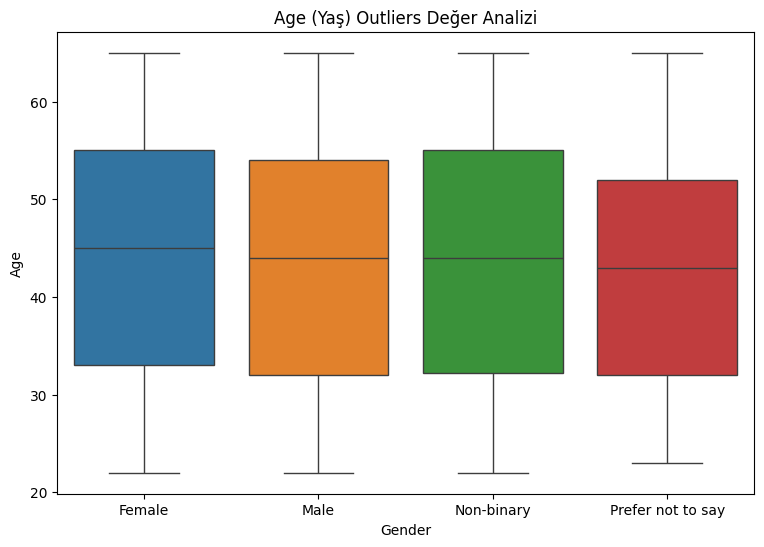

In [63]:
plt.figure(figsize=(9,6))
flierprops = dict(marker='D', markerfacecolor='black', markersize=4, alpha=1)

sns.boxplot(x="Gender", y='Age', data=df, hue='Gender',flierprops=flierprops, dodge=False)
#dodge=False parametresi kutuların sütun üzerinde tam ortalanmasını sağlar

# Legend'ı (renk açıklamasını) kapatmak grafiği sadeleştirir çünkü X ekseni zaten kategorileri yazıyor
plt.legend([], [], frameon=False) 

plt.xlabel("Gender")
plt.ylabel("Age")
plt.title('Age (Yaş) Outliers Değer Analizi')

plt.show()

# Sayısal değişkenlerde min ve max (min = Q1 - (1.5 * IQR) ,max = Q3 + (1.5 * IQR)) aralığında Outliers yoktur. 
# Datada tüm cinsiyet gruplarında 22 ve 65 yaş arasında homejen bir normal dağılım eğilimi göstermektedir. 
# Datada verilerin % 50'si (IQR) 35 ve 55 yaş arasındadır

In [65]:
Q1 = df['Hours_Per_Week'].quantile(0.25) # 1. çeyrek 
Q3 = df['Hours_Per_Week'].quantile(0.75) # 3.çeyrek 
IQR = Q3 - Q1 # %50 lik kısım 

min = Q1 - (1.5 * IQR)
max = Q3 + (1.5 * IQR)

Outliers = df[(df['Hours_Per_Week'] < min) | (df['Hours_Per_Week'] > max)] 
# belirlenen min den küçük olanları veya max değerden büyük olanları getirir
print(f"Hours_Per_Week (haftalık çalışma saati) sutünunda tespit edilen aykırı gözlem sayısı: {len(Outliers)}")

Hours_Per_Week (haftalık çalışma saati) sutünunda tespit edilen aykırı gözlem sayısı: 0


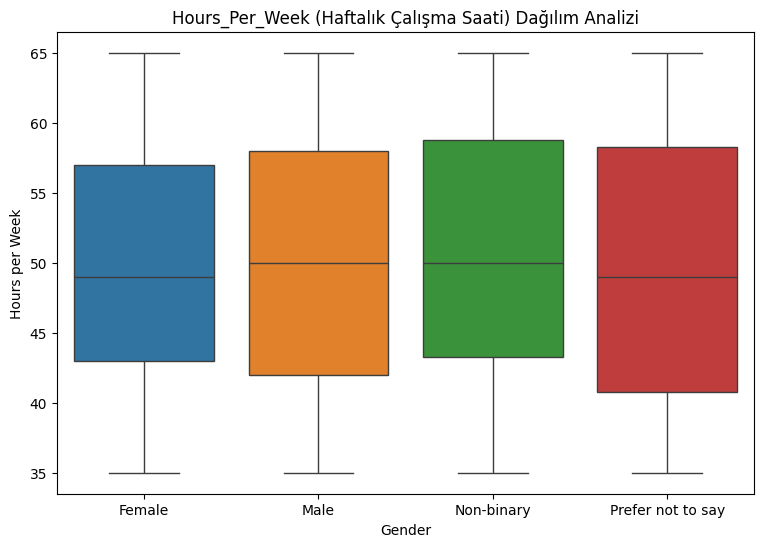

In [66]:
plt.figure(figsize=(9,6))
flierprops = dict(marker='D', markerfacecolor='black', markersize=4, alpha=1)

sns.boxplot(x="Gender", y='Hours_Per_Week', data=df, hue='Gender',flierprops=flierprops, dodge=False)
#dodge=False parametresi kutuların sütun üzerinde tam ortalanmasını sağlar

# Legend'ı (renk açıklamasını) kapatmak grafiği sadeleştirir çünkü X ekseni zaten kategorileri yazıyor
plt.legend([], [], frameon=False) 

plt.xlabel("Gender")
plt.ylabel("Hours per Week")
plt.title('Hours_Per_Week (Haftalık Çalışma Saati) Dağılım Analizi')

plt.show()

# Sayısal değişkenlerde min ve max (min = Q1 - (1.5 * IQR) ,max = Q3 + (1.5 * IQR)) aralığında Outliers yoktur. 
# Datada hafalık çalışma saatleri 35 ve 65 saat arasında homejen bir normal dağılım eğilimi göstermektedir. 
# Datada verilerin % 50'si (IQR) 42 ve 58 saat arasındadır.
# Haftalık çalışma saatinde meydan yaklaşık 50 saat civarıdır. Bir haftada standart toplam çalışma süresi 40 saattir. 
# Bu veri setinde katılımcıların genel olarak fazla mesai yaptığı söylenebilir 


In [68]:
Q1 = df['Work_Life_Balance_Score'].quantile(0.25) # 1. çeyrek 
Q3 = df['Work_Life_Balance_Score'].quantile(0.75) # 3.çeyrek 
IQR = Q3 - Q1

min = Q1 - (1.5 * IQR)
max = Q3 + (1.5 * IQR)

Outliers = df[(df['Work_Life_Balance_Score'] < min) | (df['Work_Life_Balance_Score'] > max)]
# belirlenen min den küçük olanları veya max değerden büyük olanları getirir
print(f"Work_Life_Balance_Score (iş yaşam dengesi puanı) sutünunda tespit edilen aykırı gözlem sayısı: {len(Outliers)}")

Work_Life_Balance_Score (iş yaşam dengesi puanı) sutünunda tespit edilen aykırı gözlem sayısı: 0


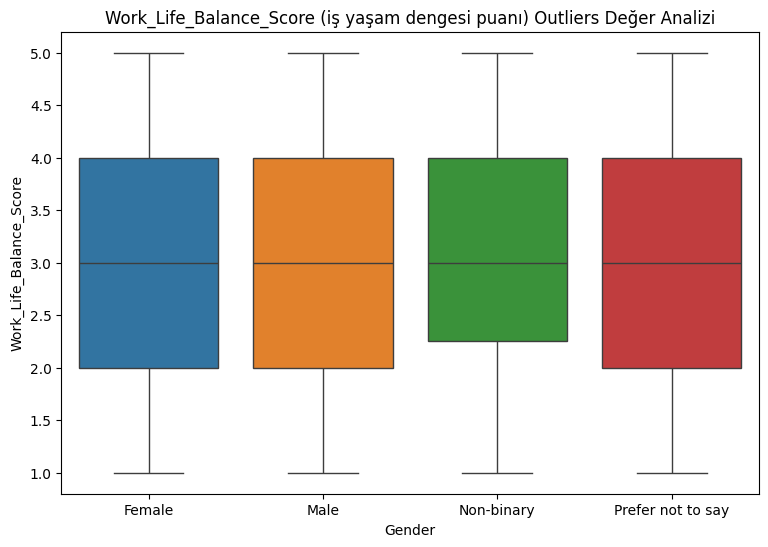

In [69]:
plt.figure(figsize=(9,6))
flierprops = dict(marker='D', markerfacecolor='black', markersize=4, alpha=1)

sns.boxplot(x="Gender", y='Work_Life_Balance_Score', data=df, hue='Gender',flierprops=flierprops, dodge=False)
#dodge=False parametresi kutuların sütun üzerinde tam ortalanmasını sağlar

plt.xlabel("Gender")
plt.ylabel("Work_Life_Balance_Score")
plt.title('Work_Life_Balance_Score (iş yaşam dengesi puanı) Outliers Değer Analizi')

plt.show()


# Sayısal değişkenlerde min ve max (min = Q1 - (1.5 * IQR) ,max = Q3 + (1.5 * IQR)) aralığında Outliers değer yoktur.
# Data setinde veriler 1-5 arasında değerler almış, grupların medyanı 3 olup normal dağılım gösterir
# Datada verilerin % 50'si (IQR) 2 ve 4 puan arasındadır.
# İş yaşam dengesi sutünündaki verilerin homojen ve dengeli olduğunu gösterir


In [70]:
# pip install scipy 
from scipy import stats # istatistik modüllerinden biridir. 

# scipy -> scientific python dan gelir. 
# z score outlier hesaplarken kullanilabilecek bir yontemdir. 
# bir verinin ortalamadan kac std uzaklikta oldugunu gosterir. 

<Figure size 800x400 with 0 Axes>

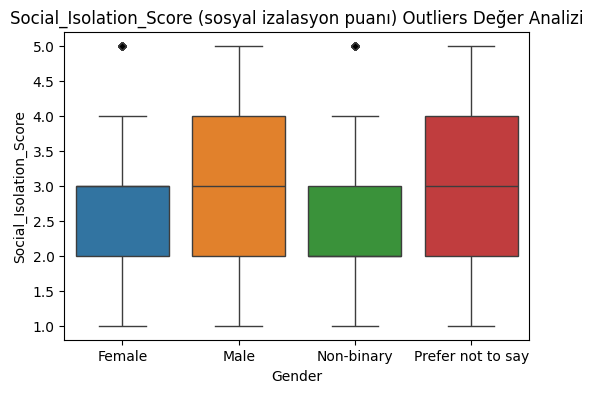

<Figure size 800x400 with 0 Axes>

In [71]:
plt.figure(figsize=(6, 4))
flierprops = dict(marker='D', markerfacecolor='black', markersize=4, alpha=1) # Outliers değerlerin 

sns.boxplot(x="Gender", y='Social_Isolation_Score', data=df, hue ='Gender', flierprops=flierprops,dodge=False)
plt.xlabel("Gender")
plt.ylabel('Social_Isolation_Score')
plt.title('Social_Isolation_Score (sosyal izalasyon puanı) Outliers Değer Analizi')
plt.figure(figsize=(8, 4))


# Sayısal değişkenlerde min ve max (min = Q1 - (1.5 * IQR) ,max = Q3 + (1.5 * IQR)) aralığında Outliers değer vardır.
# Sosyal izolasyon puanı genellikle 1 ile 4 arasında yoğunlaşırken, Female ve Non-binary gruplarında bazı bireyler "5" (tam puan) 
# vererek grubun genelinden ayrışmıştır . Z-score ile aykırı değerler incelenmiştir. 

In [72]:
z_scores = np.abs(stats.zscore(df.Social_Isolation_Score)) # absolute -> mutlak değer  alır 
outliers = np.where(z_scores > 1.5) # ortalamadan 1.5 std uzakta olan değerlerin indekslerini aldık .

In [73]:
z_scores # outlier hesaplarken kullanilabilecek bir yontemdir. otomatik hesaplar 

array([0.59290285, 0.59290285, 0.59290285, ..., 0.24835301, 1.93086473,
       0.59290285])

In [74]:
outliers # ortalamadan 1.5 std uzakta olan değerlerin indekslerini alınan outlierlar 

(array([  13,   18,   22,   23,   36,   69,   96,   99,  117,  118,  119,
         122,  129,  131,  141,  159,  166,  178,  180,  183,  188,  193,
         196,  203,  206,  209,  210,  220,  223,  247,  264,  266,  271,
         275,  283,  290,  332,  335,  368,  369,  378,  381,  387,  389,
         390,  399,  418,  423,  429,  456,  481,  486,  498,  502,  524,
         532,  547,  561,  580,  583,  584,  631,  651,  660,  668,  699,
         703,  726,  728,  767,  769,  770,  832,  839,  844,  847,  854,
         882,  884,  889,  902,  906,  907,  912,  919,  936,  973,  986,
         992,  995,  998, 1001, 1021, 1026, 1047, 1065, 1072, 1086, 1098,
        1107, 1108, 1117, 1122, 1157, 1160, 1166, 1169, 1172, 1175, 1178,
        1198, 1247, 1258, 1270, 1273, 1278, 1292, 1294, 1314, 1339, 1341,
        1356, 1360, 1364, 1373, 1377, 1397, 1416, 1425, 1431, 1436, 1437,
        1442, 1451, 1454, 1490, 1495, 1512, 1516, 1553, 1560, 1589, 1591,
        1602, 1647, 1667, 1705, 1727, 

In [75]:
df.iloc[outliers] #veri setindeki (outliers) içeren satırların tamamını bir tablo olarak ekrana getirmesini istedik

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range,mh_null,ph_null
13,2025-06-01,37,Male,Europe,Finance,UX Designer,Remote,59,Anxiety,High,5,Back Pain; Shoulder Pain; Wrist Pain,5,$60K-80K,False,False
18,2025-06-01,50,Male,North America,Education,Digital Marketing Specialist,Onsite,51,Stress Disorder,Low,4,Back Pain; Shoulder Pain,5,$100K-120K,False,False
22,2025-06-01,37,Male,South America,Manufacturing,Technical Writer,Remote,58,ADHD,High,1,Shoulder Pain,5,$60K-80K,False,False
23,2025-06-01,26,Female,South America,Customer Service,Data Analyst,Hybrid,59,Stress Disorder,Medium,2,Back Pain; Wrist Pain,5,$40K-60K,False,False
36,2025-06-01,62,Female,Asia,Education,Software Engineer,Remote,60,Stress Disorder,Medium,4,Back Pain; Eye Strain,5,$120K+,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3125,2025-06-26,53,Male,Africa,Technology,Technical Writer,Remote,63,Depression,High,3,Back Pain; Eye Strain; Wrist Pain,5,$80K-100K,False,False
3127,2025-06-26,24,Female,Oceania,Manufacturing,Quality Assurance,Remote,36,ADHD,Medium,1,Back Pain; Shoulder Pain,5,$40K-60K,False,False
3129,2025-06-26,56,Male,Africa,Healthcare,IT Support,Onsite,65,ADHD,Low,1,Back Pain; Shoulder Pain; Eye Strain; Wrist Pain,5,$60K-80K,False,False
3130,2025-06-26,63,Male,South America,Customer Service,Executive Assistant,Remote,46,ADHD,Medium,3,Back Pain,5,$80K-100K,False,False


In [76]:
mean = df["Social_Isolation_Score"].mean()
std = df["Social_Isolation_Score"].std()

upper_limit = mean + 1.5 * std #outlierlar üst limit üstünde olduğu için datayı sıkılaştırdık 

df["Social_Isolation_Score"] = df["Social_Isolation_Score"].astype(float) #integer tam sayıyı iafede eder hata verir.
#data tipi floata çevrildi

df.loc[ df["Social_Isolation_Score"] > upper_limit, "Social_Isolation_Score"] = upper_limit

# Data verileri 2-4 aralığında toplanmış olup grupların medyan değeri 3 tür. Veri setinin genel kitlesi benzer sosyal izalasyona sahiptir
# Sosyal izolasyon puanlaması gibi psikolojik ölçeklerde bazı kişilerin en uç puanı alması çok doğaldır;
# bu bir hata değil, uç bir durumdur.En uç grubu silmek gerçek hayatın uç örneklerini analizden çıkarmak olur. 
# Bu sebeple aykırı değerler veri setinin genel yapısını bozacak kadar uzak olmadığı için silinmemiş, 
# üst limitler 1.5 standartsapma  sıkıştırılmıştır.

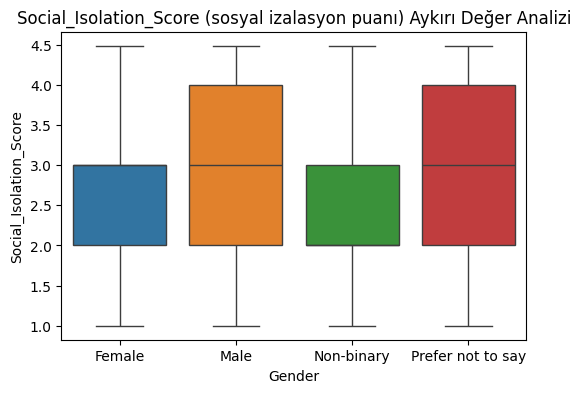

<Figure size 800x400 with 0 Axes>

In [77]:
plt.figure(figsize=(6, 4))
flierprops = dict(marker='D', markerfacecolor='black', markersize=4, alpha=1) #outlier değerlerin 

sns.boxplot(x="Gender", y='Social_Isolation_Score', data=df, hue ='Gender', flierprops=flierprops, dodge=False)
plt.xlabel("Gender")
plt.ylabel('Social_Isolation_Score')
plt.title('Social_Isolation_Score (sosyal izalasyon puanı) Aykırı Değer Analizi')
plt.figure(figsize=(8, 4));




### 🔍 5. Keşifsel Veri Analizi (EDA)

**Adımlar:**
- Temel istatistikleri özetle.
- Kategorik değişkenler için frekans tabloları oluştur.
- Korelasyon analizi yap.
- Gruplar arası karşılaştırmalar yap.

**Sorular:**
1. Hangi değişkenler arasında güçlü bir korelasyon var?
2. Uzaktan çalışma süresi sağlık göstergelerini nasıl etkiliyor?
3. Hangi yaş grubu en yüksek stres seviyesine sahip?

In [78]:
df.describe().T
# Age; 22-65 aralığında değerler alırken ortalaması 43 tür. ortalama medyanan çok yakındır veri normal dağılım göstermektedir. 
# Hour Per Week; haftalık çalışma saatleri 35-65 arasında değerler alırken ortalaması 49 dur. 
# Ortalama medyanan çok yakındır veri normal dağılım göstermektedir
# Work Life Balance Score; 1- 5 arasında değer alır, ortalaması 3 tür. Ortalama medyanan çok yakındır veri normal dağılım göstermektedir
# Social Isolation Score; 1- 5 arasında değer alır, ortalaması 2.6dır.

,count,mean,min,25%,50%,75%,max,std
Survey_Date,3157,2025-06-13 13:29:37.763699,2025-06-01 00:00:00,2025-06-07 00:00:00,2025-06-14 00:00:00,2025-06-20 00:00:00,2025-06-26 00:00:00,NaN
Age,3157.0,43.732024,22.0,33.0,44.0,55.0,65.0,12.661095
Hours_Per_Week,3157.0,49.904973,35.0,42.0,50.0,57.0,65.0,8.897699
Work_Life_Balance_Score,3157.0,2.996516,1.0,2.0,3.0,4.0,5.0,1.163307
Social_Isolation_Score,3157.0,2.661815,1.0,2.0,3.0,4.0,4.488114,1.111892


In [79]:
# Data setinin temel istatistikleri özet tablosu 
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(exclude="category").min()
    Max = df.select_dtypes(exclude="category").max() # min ve max değerde kategorik sütunları atladık 
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

summary(df)

Data shape: (3157, 16)
___________________________
Data Types:
Types
int64             3
bool              2
category          1
category          1
category          1
category          1
category          1
category          1
category          1
category          1
float64           1
datetime64[us]    1
category          1
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
Age,int64,3157,44,0,22,65
Burnout_Level,category,3157,3,0,NaN,NaN
Gender,category,3157,4,0,NaN,NaN
Hours_Per_Week,int64,3157,31,0,35,65
Industry,category,3157,9,0,NaN,NaN
Job_Role,category,3157,24,0,NaN,NaN
Mental_Health_Status,category,3157,6,0,NaN,NaN
Physical_Health_Issues,category,3157,31,0,NaN,NaN
Region,category,3157,6,0,NaN,NaN
Salary_Range,category,3157,5,0,NaN,NaN


In [80]:
kategorik_sutunlar = df.select_dtypes(include=['category']).columns
kategorik_sutunlar # kategorik sütunları belirledik 

Index(['Gender', 'Region', 'Industry', 'Job_Role', 'Work_Arrangement',
       'Mental_Health_Status', 'Burnout_Level', 'Physical_Health_Issues',
       'Salary_Range'],
      dtype='str')

In [81]:
for sutun in kategorik_sutunlar:
    print(f"\n--- {sutun} Frekans Tablosu ---")
    print(df[sutun].value_counts(dropna=False))
    print("-" * 30) 
# data frame daki tüm kategorik sütunların frekans tablosunu oluşturduk 


--- Gender Frekans Tablosu ---
Gender
Male                 1535
Female               1500
Non-binary             90
Prefer not to say      32
Name: count, dtype: int64
------------------------------

--- Region Frekans Tablosu ---
Region
South America    575
Africa           532
Oceania          523
Asia             517
Europe           513
North America    497
Name: count, dtype: int64
------------------------------

--- Industry Frekans Tablosu ---
Industry
Professional Services    730
Technology               593
Manufacturing            370
Finance                  367
Education                287
Healthcare               247
Marketing                202
Retail                   188
Customer Service         173
Name: count, dtype: int64
------------------------------

--- Job_Role Frekans Tablosu ---
Job_Role
Research Scientist              151
DevOps Engineer                 149
Customer Service Manager        144
Social Media Manager            144
Data Analyst                  

In [82]:
# Korelasyon sayısal değerler arasındaki ilişki olduğu için integer sütunları arasında incelenir. 
# df ten sayısal değerler select_dtypes ile çağrılırıp numeric_cols olarak yeni bir data oluşur 

numeric_df = df.select_dtypes(include=['int','float'])
numeric_df

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score
0,27,64,3,2.000000
1,37,37,4,2.000000
2,32,36,3,2.000000
3,40,63,1,2.000000
4,30,65,5,4.000000
...,...,...,...,...
3152,62,38,4,3.000000
3153,24,54,4,4.000000
3154,45,59,1,3.000000
3155,38,52,3,4.488114


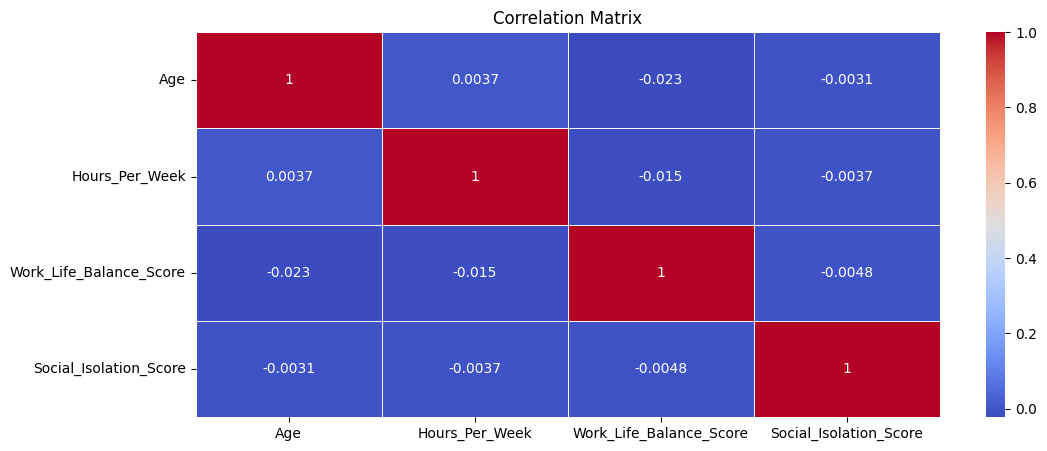

In [83]:
corr_matrix = numeric_df.corr() #Korelasyon matrisini hesaplar  

plt.figure(figsize=(12,5)) 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
# annot : True korelasyon sonuçlarını yazdırır
# linewidths=0.5 çizği kalınlığı 
plt.title("Correlation Matrix")
plt.show()

# Korelasyonda  +1: Mükemmel pozitif ilişki (Biri artınca diğeri de artar).
                    # -1: Mükemmel negatif ilişki (Biri artınca diğeri azalır).
                    # 0: İlişkisizlik, birbirlerini etkilemez. 
# Korelasyondaki değerler 0 çok yakın değerlerdir. Anlamlı bir doğrusal ilişki yok denilebilir.
#  Sosyal İzalasyon;
    # Sosyal izalasyon yaş arasındaki koralasyon: -0.0031
    # Sosyal izalasyon haftalık çalışma saati arasındaki koralasyon: -0.0037
    # Sosyal izalasyon iş yaşam dengesi arasındaki koralasyon: -0.0048
    # Sosyal izalasyon yaş ,haftalık çalışma saati , iş yaşam dengesi ile korolasyonlarına ayarı ayrı bakıldığında 
    # negatif yönde dorğrusal bir ilişki olduğu görülmektedir.
    # Sosyal izalasyonsosyal puanında diğer değişkenlere bağlı olarak teryönde artış olduğu saptanmıştır . 
    # Pandemi döneminde uzaktan çalışmak her yaş grubunu farklı derecede, farklı nedenlerle etkilemiş olabilir 
# İş Yaşam Dengesi;
    # İş yaşam dengesi yaş arasındaki korelasyon: -0.023
    # İş yaşam dengesi haftalık çalışma saati arasındaki korelasyon:-0.015
    # Yaş arttıkça iş yaşam dengesinin bozulduğu görülüyor.Negatif yönde bir korelasyon vardır. 
    # Yaş ilerledikçe artan yetki ve sorumluluk özel hayata problemler yaratabilir.
    # iş yaşam dengesi ile haftalık çalışma saatleri arasında negatif yönde bşr korelasyon vardır. 
    # Haftalış çalışma saatleri arttıkça iş yaşam dengesi bozulmaktadır 
# Yaş
    # Yaş ve haftalık çalışma saati korelasyonu (Korelasyon= 0.0037)
    # Yaş ile haftalık çalışma saati arasında pozitif yönde dorğrusal bir ilişki olduğu görülmektedir.
    # 0.0037 korelasyon değeri çok küçük olsada yaş ilerledikçe haftalık çalışma saatlerinde çok küçük artış olduğunu gösterir.



### 2. Uzaktan çalışma süresi sağlık göstergelerini nasıl etkiliyor? kaldım

In [121]:
df['Hours_Per_Week'].max()

np.int64(65)

In [122]:
df['Hours_Per_Week'].min()

np.int64(35)

In [ ]:
bins = [35, 45, 55, 65]
labels = ["35-44", "45-54", "55-65"]
df['Hours_Per_Week'] = pd.cut(df['Hours_Per_Week'], bins=bins, labels=labels)
# haftalık çalışma saatini gruplandırdık haftalık çalışma saatine göre sağlık göstergeleri grafiğini çizdik  

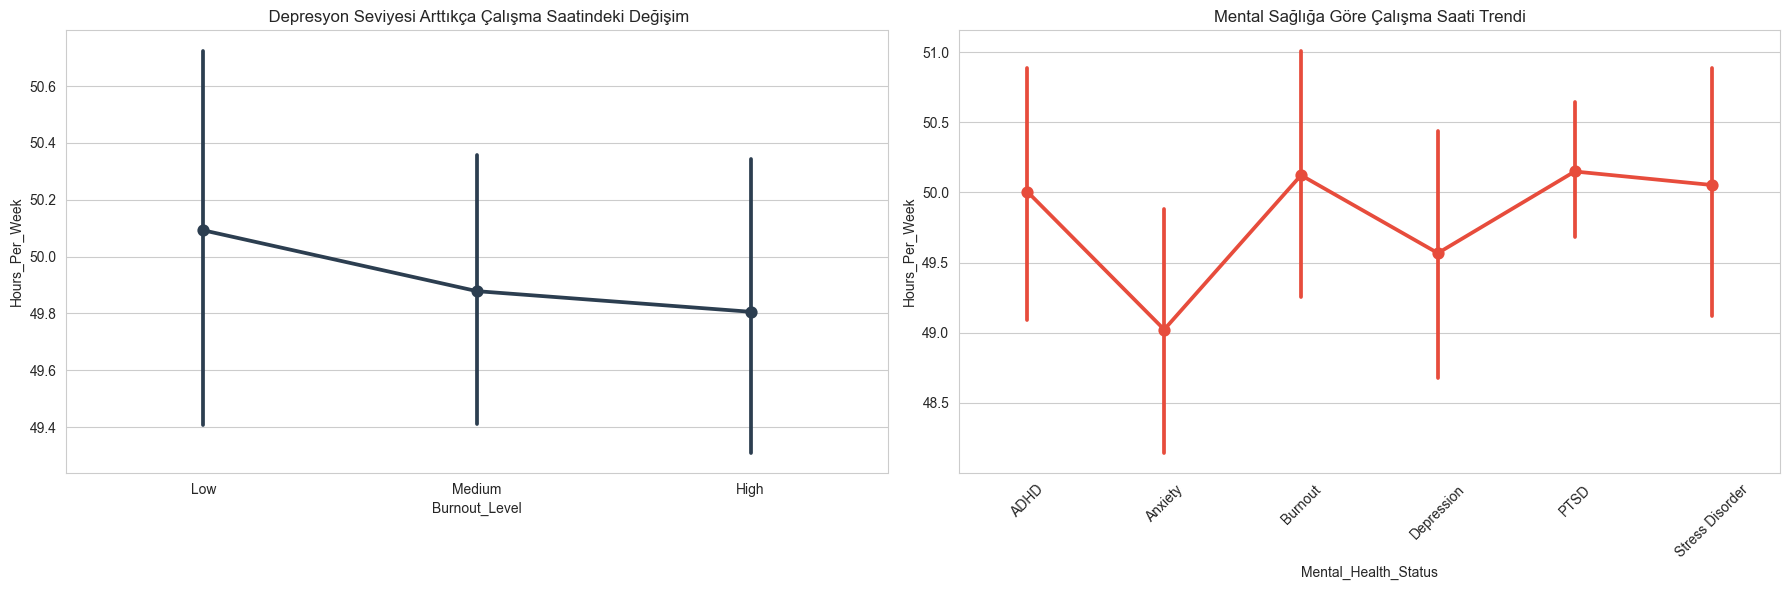

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.pointplot(data=df, x="Burnout_Level", y="Hours_Per_Week", 
              order=["Low", "Medium", "High"], ax=axes[0], color="#2c3e50")
axes[0].set_title(" Depresyon Seviyesi Arttıkça Çalışma Saatindeki Değişim")

sns.pointplot(data=df, x="Mental_Health_Status", y="Hours_Per_Week", 
              ax=axes[1], color="#e74c3c")
axes[1].set_title("Mental Sağlığa Göre Çalışma Saati Trendi")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# pointplot, Nokta Grafiği kullanarak değişimi vurguladık.
# Grafiktelerde çalışma saati arttıkça Burnout_Level depresyon seviyesinde artış olduğu  ve mental sağlığı olumsuz etkilediği görülüyor

### 3. Hangi yaş grubu en yüksek stres seviyesine sahip? kontrol et 

In [103]:
df['Age'].min()

np.int64(22)

In [104]:
df['Age'].max()

np.int64(65)

In [ ]:
bins = [22, 32, 42, 52, 65]
labels = ["22-31", "32-41", "42-51", "52-65"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
# yaşları gruplandırdık yaş gruplarınna göre stres seviyesinin grafiğini çizdik 

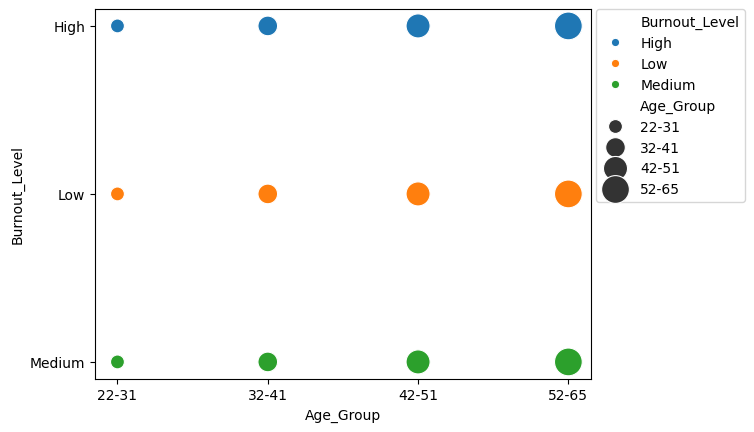

In [ ]:
ax = sns.scatterplot (data=df, x='Age_Group',
                y='Burnout_Level', hue='Burnout_Level', size='Age_Group', sizes=[s for s in range(100,1200,100)], legend=True)

h, l = ax.get_legend_handles_labels()

ax.legend(h[0:9], l[0:9],  loc=2,bbox_to_anchor=(1.01, 1), borderaxespad=0., fontsize=10)
plt.show()

#hue='Burnout_Level'noktaların rengi stres seviyesine göre değişecek 
# size='Age_Group' nokta grubu yaş grubuna göre değişecek 
# noktaların alabileceği boyut aralığı 
#bbox_to_anchor=(1.01, 1), grafiğin dışına taşır açıklama kutusunu
#Legend içindeki:h → renk / boyut simgeleri l → yazıları

# stres seviyesi en yüksek düzeyde 52-65  yaş aralığında görünmektedir  görünmektedir 


### 📊 6. Veri Görselleştirme

**Adımlar:**
- Histogram, bar chart, scatter plot, pairplot, heatmap, line plot oluştur.
- Görselleştirmelerde sade ve anlamlı renk paletleri seç.

**Sorular:**
1. Stres seviyesi dağılımı nasıldır?
2. Uyku süresi ile üretkenlik arasında nasıl bir ilişki var?
3. Cinsiyet veya yaş grubu bazında sağlık göstergeleri farklı mı?

In [ ]:
# Stres seviyesi dağılımı nasıldır?

print(df['Burnout_Level'].value_counts()) # sütunda ne kadar veri var onu kontrol ettik 

print(df['Burnout_Level'].value_counts(normalize=True) * 100) # Oransal (yüzde) dağılımı hesapladık 

Burnout_Level
Medium    1366
High      1046
Low        745
Name: count, dtype: int64
Burnout_Level
Medium    43.268926
High      33.132721
Low       23.598353
Name: proportion, dtype: float64


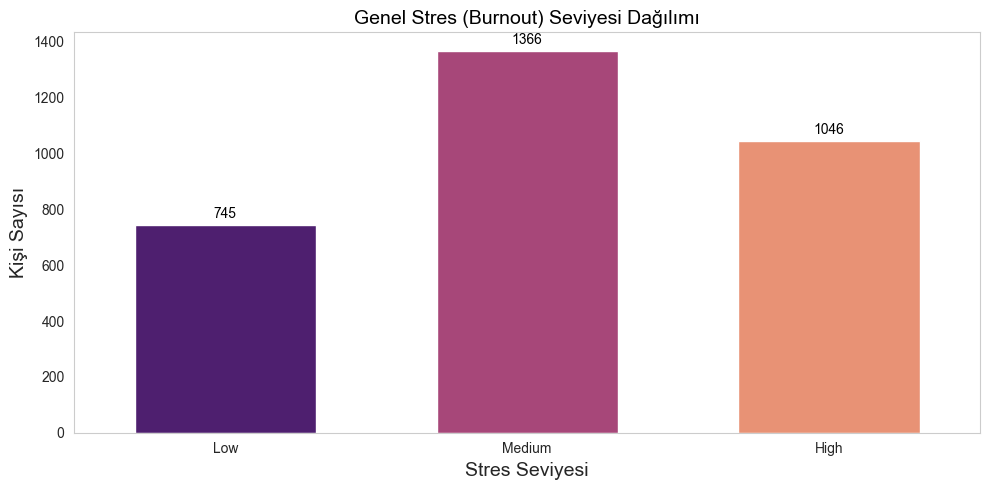

In [ ]:
# Stres dağılım grafiğini (Düşük -> Orta -> Yüksek sıralamasıyla) göterildi 
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x='Burnout_Level', order=['Low', 'Medium', 'High'], palette='magma',width=0.6)
# width=0.5  barları incelttik

for container in ax.containers:
    ax.bar_label(container,  label_type='edge', fontsize=10, color='black', padding=3) 

ax.grid(False) # arka plandaki çizgileri kaldırır 

plt.title('Genel Stres (Burnout) Seviyesi Dağılımı', fontsize=14, color = 'black') # başlık font boyutu büyüsün
plt.xlabel('Stres Seviyesi', fontsize=14) # x ekseni başlık font boyutu
plt.ylabel('Kişi Sayısı', fontsize=14) # y ekseni başlık font boyutu
plt.xticks(fontsize=10, rotation=0) # x ekseni font boyutu ve hizalama ayarları
plt.yticks(fontsize=10) # y ekseni font boyutu
plt.tight_layout()

plt.show()

# stres seviyesi medium orta seviyededir 


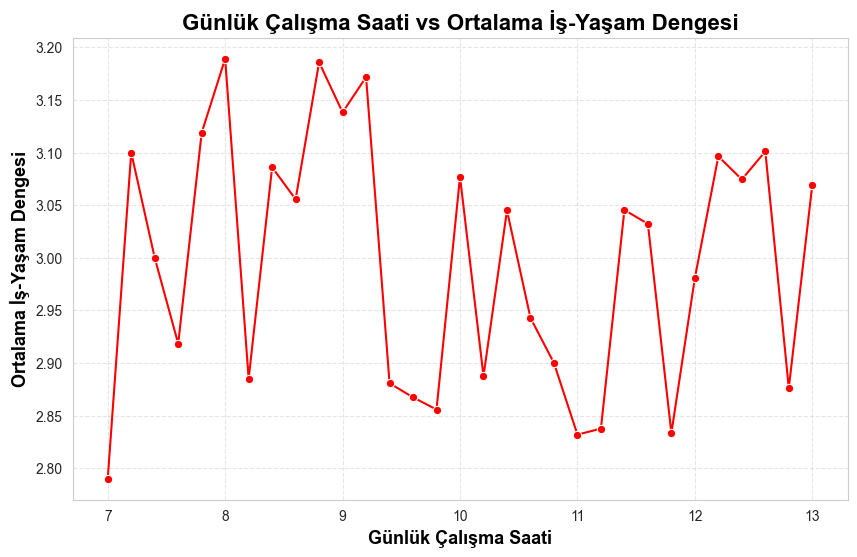

In [ ]:
#2. Uyku süresi ile üretkenlik arasında nasıl bir ilişki var?
plt.figure(figsize=(10,6))

# Haftalık çalışma saatini 5 güne bölerek günlük çalışma saati oluştur
avg_score = df.groupby('Hours_Per_Week')['Work_Life_Balance_Score'].mean().reset_index()
avg_score['Daily_Work_Hours'] = avg_score['Hours_Per_Week'] / 5  # Günlük çalışma saati

# Line plot
sns.lineplot(data=avg_score, x='Daily_Work_Hours', y='Work_Life_Balance_Score', marker='o', color='red')

# Başlık ve eksenler
plt.title('Günlük Çalışma Saati vs Ortalama İş-Yaşam Dengesi', fontsize=16, color='black', fontweight='bold')
plt.xlabel('Günlük Çalışma Saati', fontsize=13, color='black', fontweight='bold')
plt.ylabel('Ortalama İş-Yaşam Dengesi', fontsize=13, color='black', fontweight='bold')

# Ekseni ayarları
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#İş-yaşam dengesinin günlük çalışma saatlerine göre çok hassas ve değişken olduğunu gösteriyor. 
# Her saat diliminde farklı bir "denge tecrübesi" yaşanıyor.
# Üretkenlik şu an 8-9 saatlik "güvenli bölgede" optimize edilmiş durumda.
# Ancak 10 saati aşan mesailerde denge skoru dramatik şekilde dalgalandığı için,
#  bu saatlerde yapılan işin kalitesi ve sürekliliği ciddi risk taşıyor.

In [ ]:
#. Cinsiyet veya yaş grubu bazında sağlık göstergeleri farklı mı?

In [174]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

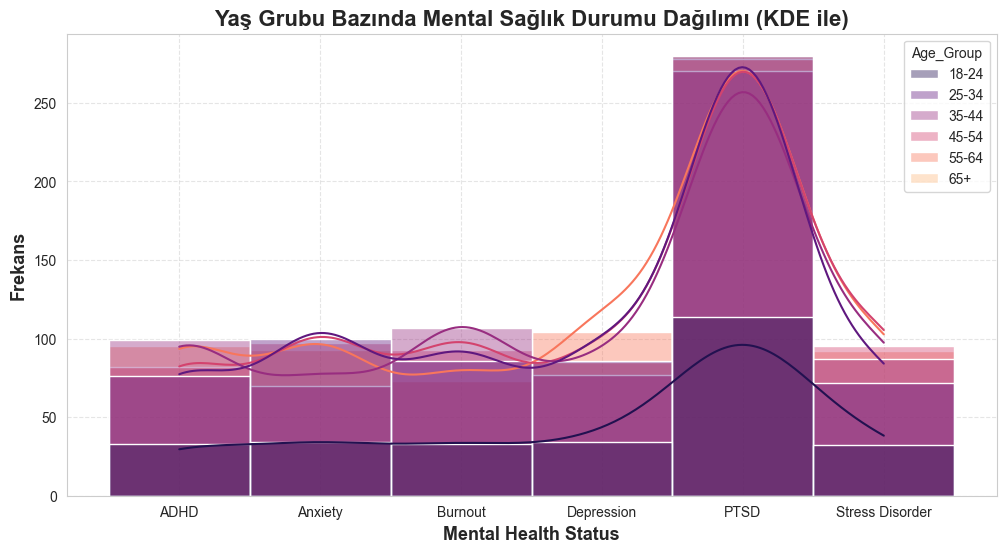

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(data=df, x='Mental_Health_Status', hue='Age_Group', bins=15, kde=True, palette='magma', alpha=0.4)

plt.title('Yaş Grubu Bazında Mental Sağlık Durumu Dağılımı (KDE ile)', fontsize=16, fontweight='bold')
plt.xlabel('Mental Health Status', fontsize=13, fontweight='bold')
plt.ylabel('Frekans', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# PTSD Vurgusu: Son grafikte (KDE ile mental sağlık durumu), PTSD (Travma Sonrası Stres Bozukluğu) tanısının
# yaş diğer tüm kategorilere göre (Anksiyete, Depresyon vb.) devasa bir farkla öne çıktığı görülüyor.
# Yaş Dengesi: Diğer mental sağlık durumları yaş arasında daha dengeli dağılırken,
# PTSD'nin bu kadar baskın olması,çalışma ortamında veya geçmiş dönemde (pandemi vb.) 
# yaşanan travmatik olayların etkisinin sürdüğünü kanıtlıyor.

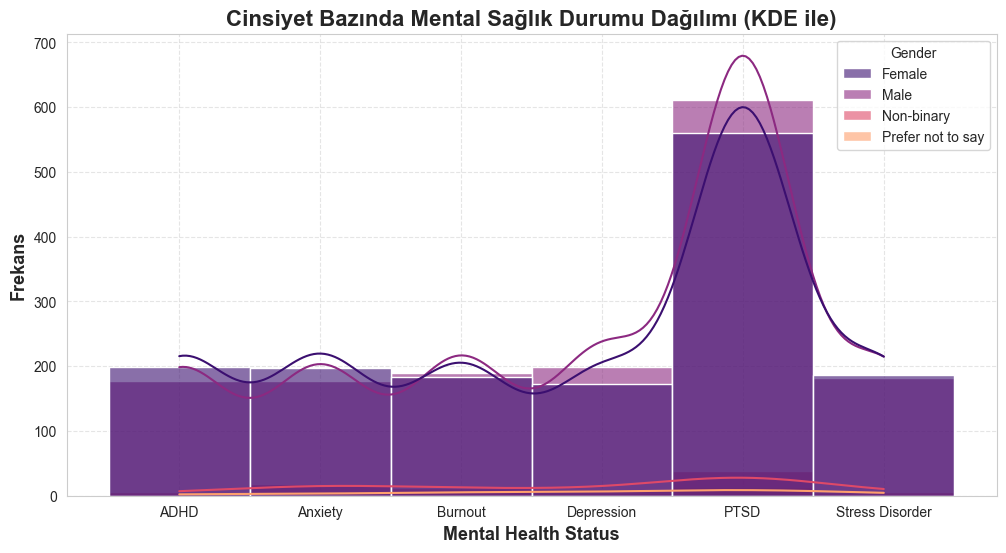

In [186]:
plt.figure(figsize=(12,6))

sns.histplot(data=df, x='Mental_Health_Status', hue='Gender', bins=15, kde=True, palette='magma', alpha=0.6)
plt.title('Cinsiyet Bazında Mental Sağlık Durumu Dağılımı (KDE ile)', fontsize=16, fontweight='bold')
plt.xlabel('Mental Health Status', fontsize=13, fontweight='bold')
plt.ylabel('Frekans', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# PTSD Vurgusu: Son grafikte (KDE ile mental sağlık durumu), PTSD (Travma Sonrası Stres Bozukluğu) tanısının
# hem kadınlarda hem de erkeklerde diğer tüm kategorilere göre (Anksiyete, Depresyon vb.) devasa bir farkla öne çıktığı görülüyor.
# Cinsiyet Dengesi: Diğer mental sağlık durumları cinsiyetler arasında daha dengeli dağılırken,
# PTSD'nin bu kadar baskın olması,çalışma ortamında veya geçmiş dönemde (pandemi vb.) 
# yaşanan travmatik olayların etkisinin sürdüğünü kanıtlıyor.

In [190]:
# Pivot table: satır=Region, sütun=Industry, değer=ortalama veya sayım
heat_data = df.pivot_table(index='Region', columns='Industry', 
                           values='Salary_Range', aggfunc='count')  # count ile yoğunluk
heat_data = heat_data.fillna(0)  # boş değerleri 0 yap

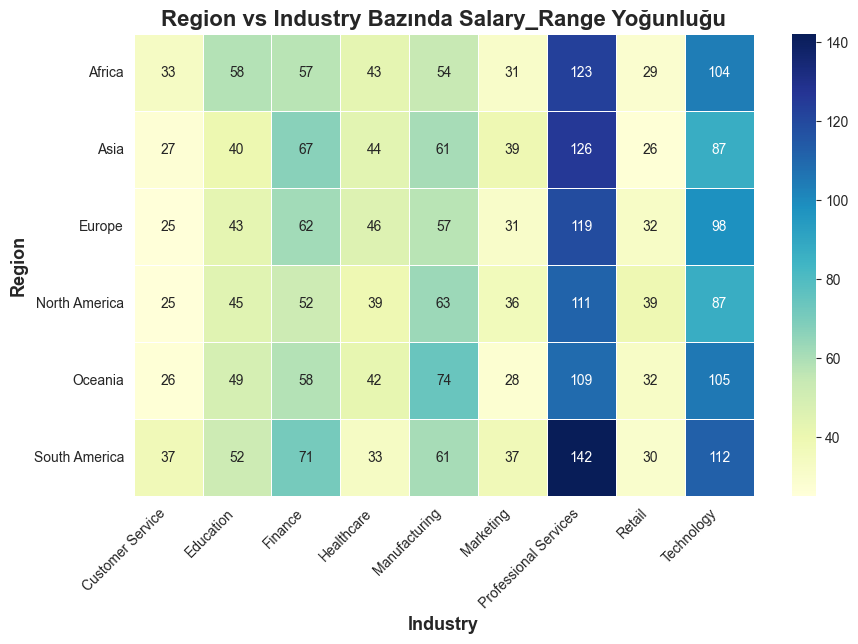

In [ ]:
#Region ve Industry Bazında Salary_Range Yoğunluğu
plt.figure(figsize=(10,6))
sns.heatmap(heat_data, annot=True, fmt='g', cmap='YlGnBu', linewidths=0.5)

plt.title('Region ve Industry Bazında Salary_Range Yoğunluğu', fontsize=16, fontweight='bold')
plt.xlabel('Industry', fontsize=13, fontweight='bold')
plt.ylabel('Region', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

#  grafikte en yoğun grubun professional servis ve technology alanı olduğunu gösterir. 
# South America da professional servis alınında çaılma yüksektir. 
#iş gücü piyasasının "Profesyonel Hizmetler" ve "Teknoloji" ekseninde döndüğünü, 
# perakende ve pazarlama gibi alanların ise bu veri setinde çok daha küçük bir yer kapladığını kanıtlıyor.

### 🧩 7. Özet ve Yorum

**Adımlar:**
- Temizleme ve analiz sürecinde neler öğrendiğini özetle.
- Veri kalitesi hakkında çıkarım yap.
- Ek analizler öner.

**Sorular:**
1. Veri seti analiz için yeterince temiz hale geldi mi?
2. Daha fazla veri toplansa hangi özellikler anlamlı olurdu?
3. Analiz sonucunda hangi önlemler uzaktan çalışanların sağlığını iyileştirebilir?

######
 - Veri setinde 1079 tane veri kaybı vardı. Temiz bir veri değildi. 
 - Veri inceleme sürecinde eksik veriler doldurulup datatyplerı düzenlendi. 
 - Datada özellikler arasında korolasyon incelendiğinde -0.023 ve  + 0.0037 arasında değer aldığını gösterir.
 - Korolasyonda +1 pozitif yönde mükemmel ilişki ,-1 negatif yönde mükemmel ilişki , 0 ilişkisiz birbirini etkilemez. 
 - Datada verilerin korolasyonu nerdeyse önemsenmeyecek seviyede olup sıfıra yakındır .
 - Buda veriler arasında ilişki olmadığını gösterir. 
 - Çalışma saatlerinin iyileştirilmesi, maaş uzaktan çalışanların sağlığını iyileştirebilir.